 - NLP Text Classification
This notebook demonstrates a complete text classification pipeline using TF-IDF and Naive Bayes.

## 1. Import Tools

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kwakuopokuagyeman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kwakuopokuagyeman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 2. Load and Explore Data

In [3]:
df = pd.read_json("dataset.json")
df.head()

,text,date,label,id,label_name
0,The {@Clinton LumberKings@} beat the {@Cedar R...,2019-09-08,4,1170516324419866624,sports_&_gaming
1,I would rather hear Eli Gold announce this Aub...,2019-09-08,4,1170516440690176006,sports_&_gaming
2,"Someone take my phone away, I’m trying to not ...",2019-09-08,4,1170516543387709440,sports_&_gaming
3,"A year ago, Louisville struggled to beat an FC...",2019-09-08,4,1170516620466429953,sports_&_gaming
4,Anyone know why the #Dodgers #Orioles game nex...,2019-09-08,4,1170516711411310592,sports_&_gaming


In [4]:
print(df.columns)
print(df.shape)
print(df.dtypes)

Index(['text', 'date', 'label', 'id', 'label_name'], dtype='object')
(6443, 5)
text                  object
date          datetime64[ns]
label                  int64
id                     int64
label_name            object
dtype: object


In [5]:
df = df[['text', 'label_name']]
print("Null values:")
print(df.isnull().sum())

Null values:
text          0
label_name    0
dtype: int64


In [6]:
print("Label distribution:")
print(df['label_name'].value_counts())

Label distribution:
label_name
pop_culture                 2512
sports_&_gaming             2291
daily_life                   883
science_&_technology         326
business_&_entrepreneurs     287
arts_&_culture               144
Name: count, dtype: int64


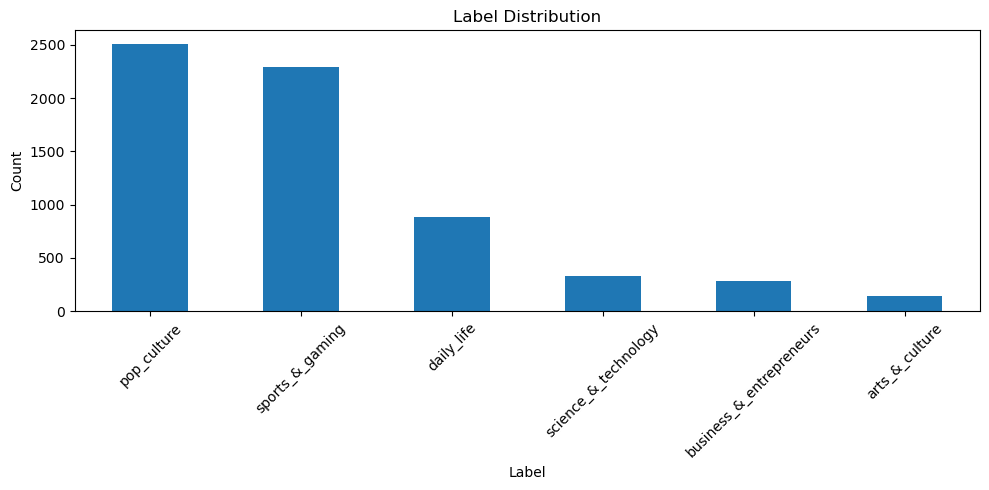

In [7]:
df['label_name'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Clean Text

In [1]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [9]:
df['clean_text'] = df['text'].apply(clean_text)
print("First 3 original texts:")
print(df['text'].head(3))
print("\nFirst 3 cleaned texts:")
print(df['clean_text'].head(3))

First 3 original texts:
0    The {@Clinton LumberKings@} beat the {@Cedar R...
1    I would rather hear Eli Gold announce this Aub...
2    Someone take my phone away, I’m trying to not ...
Name: text, dtype: object

First 3 cleaned texts:
0    clinton lumberkings beat cedar rapids kernels ...
1    would rather hear eli gold announce auburn gam...
2    someone take phone away im trying look chicago...
Name: clean_text, dtype: object


In [10]:
X = df['clean_text']
y = df['label_name']

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Features shape: (6443,)
Labels shape: (6443,)


## 4. Split Clean Data into Train and Test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 5154
Test set size: 1289


In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")
print(f"Number of features: {len(vectorizer.get_feature_names_out())}")

Training TF-IDF shape: (5154, 5000)
Test TF-IDF shape: (1289, 5000)
Number of features: 5000


## 5. TF-IDF Vectorization & Training

In [13]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
print("Model training completed!")

Model training completed!


In [14]:
y_pred = model.predict(X_test_tfidf)
print(f"Predictions generated for {len(y_pred)} test samples")

Predictions generated for 1289 test samples


## 6. Predicting and Evaluating

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7393


In [16]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[  0   0   1  19   0   5]
 [  0   2   6  27   1  24]
 [  0   0  46  97   0  36]
 [  0   0   1 459   0  37]
 [  0   0   1  43   2  14]
 [  0   0   0  24   0 444]]


In [17]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                          precision    recall  f1-score   support

          arts_&_culture       0.00      0.00      0.00        25
business_&_entrepreneurs       1.00      0.03      0.06        60
              daily_life       0.84      0.26      0.39       179
             pop_culture       0.69      0.92      0.79       497
    science_&_technology       0.67      0.03      0.06        60
         sports_&_gaming       0.79      0.95      0.86       468

                accuracy                           0.74      1289
               macro avg       0.66      0.37      0.36      1289
            weighted avg       0.75      0.74      0.68      1289



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
